In [ ]:
# Finance Project 
# In this project our main goal is to Red flag the financial orgination to avoid delinquency. 
# To achive our goal we will perform exploratary data analysis to find the relationship with columns, manupliation of data to 
# to understand the information provided. 
# Build a model to check the accuracy, wheather the model explore and support the goal of our project. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno # 



In [2]:
# Data Processing using pandas
# We create a path to extract the data set from any location using the path. 
# Header = 0 will make use the first row as column / which is default given) 
path = '/Users/thiyagarajanjana/Desktop/loan_default_prediction_project_complete.csv'
df = pd.read_csv(path, header= 0)
df


,Age,Gender,Income,Employment_Status,Location,Credit_Score,Debt_to_Income_Ratio,Existing_Loan_Balance,Loan_Status,Loan_Amount,Interest_Rate,Loan_Duration_Months
0,56,Male,91910.323246,Employed,Urban,615,0.462601,3580.203540,Non-Default,27160.609602,11.562543,27
1,46,Male,81880.547904,NaN,Urban,702,0.637618,38762.098480,Non-Default,22931.663587,5.241453,54
2,32,NaN,89696.082900,Unemployed,Suburban,747,0.431507,8412.342168,Non-Default,6787.299376,6.928529,55
3,60,Male,37123.175342,NaN,Suburban,846,0.421620,2051.077370,Non-Default,29646.934665,14.422941,17
4,25,Male,67655.479665,Unemployed,Rural,425,0.431039,29518.957965,Default,11137.769677,10.970186,21
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,33,Male,94318.593216,Employed,Rural,359,0.458550,32652.095340,Non-Default,13581.669336,15.286204,58
9996,29,Female,22480.468746,Employed,Urban,671,0.310884,30803.407227,Non-Default,28718.251112,6.409365,71
9997,18,Male,88172.496665,Employed,Urban,441,0.282163,8665.007815,Default,22755.220904,8.818762,51
9998,25,NaN,51788.871823,Employed,Rural,417,0.370681,36921.116660,Non-Default,29066.184090,14.516478,50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  int64  
 1   Gender                 8005 non-null   object 
 2   Income                 10000 non-null  float64
 3   Employment_Status      9013 non-null   object 
 4   Location               10000 non-null  object 
 5   Credit_Score           10000 non-null  int64  
 6   Debt_to_Income_Ratio   10000 non-null  float64
 7   Existing_Loan_Balance  10000 non-null  float64
 8   Loan_Status            10000 non-null  object 
 9   Loan_Amount            10000 non-null  float64
 10  Interest_Rate          10000 non-null  float64
 11  Loan_Duration_Months   10000 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 937.6+ KB


In [4]:
# describe method explain the distribution of data under various criteria. 
# The data explain the minimum, Maximam and the percentile of the numerical values..
# ..(which is below the percentage of each numerical column)
# eg: if you take the age column 10% of the customer's are below 22 years, likewise 70% of the customers are below 50 years of age. 

df.describe(percentiles=[0.10,0.20,0.30,0.70])


,Age,Income,Credit_Score,Debt_to_Income_Ratio,Existing_Loan_Balance,Loan_Amount,Interest_Rate,Loan_Duration_Months
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.054000,60026.281455,575.114100,0.505075,24987.100093,27420.008134,11.520288,41.251400
std,13.484104,23325.125697,156.836488,0.288439,14553.399559,12929.128033,4.904728,17.309152
min,18.000000,20000.743678,250.000000,0.000048,5.755463,5021.968396,3.003891,12.000000
10%,22.000000,28041.708110,355.000000,0.104170,4762.977777,9557.262186,4.688078,18.000000
20%,27.000000,35818.420622,413.000000,0.206193,9869.332772,14021.323196,6.410045,23.000000
30%,32.000000,43661.613626,470.000000,0.306186,14985.983300,18303.022226,8.141856,29.000000
50%,41.000000,59841.754386,578.000000,0.504999,24815.252605,27465.829975,11.572578,41.000000
70%,50.000000,76267.000914,683.000000,0.712011,35098.216566,36398.627455,14.902900,53.000000
max,64.000000,150000.000000,849.000000,0.999895,49983.832438,49983.285870,19.998504,71.000000


In [5]:
# Creating group for age(continues Column)
bins=[10,20,40,50,70]
lables=['10-20','20-40','40-60','60-80']
df['Age_groups']=pd.cut(df["Age"],bins=bins,labels=lables,right=False)

In [6]:
# Head diaplaying top 5 row of data.
df.head()


,Age,Gender,Income,Employment_Status,Location,Credit_Score,Debt_to_Income_Ratio,Existing_Loan_Balance,Loan_Status,Loan_Amount,Interest_Rate,Loan_Duration_Months,Age_groups
0,56,Male,91910.323246,Employed,Urban,615,0.462601,3580.203540,Non-Default,27160.609602,11.562543,27,60-80
1,46,Male,81880.547904,NaN,Urban,702,0.637618,38762.098480,Non-Default,22931.663587,5.241453,54,40-60
2,32,NaN,89696.082900,Unemployed,Suburban,747,0.431507,8412.342168,Non-Default,6787.299376,6.928529,55,20-40
3,60,Male,37123.175342,NaN,Suburban,846,0.421620,2051.077370,Non-Default,29646.934665,14.422941,17,60-80
4,25,Male,67655.479665,Unemployed,Rural,425,0.431039,29518.957965,Default,11137.769677,10.970186,21,20-40


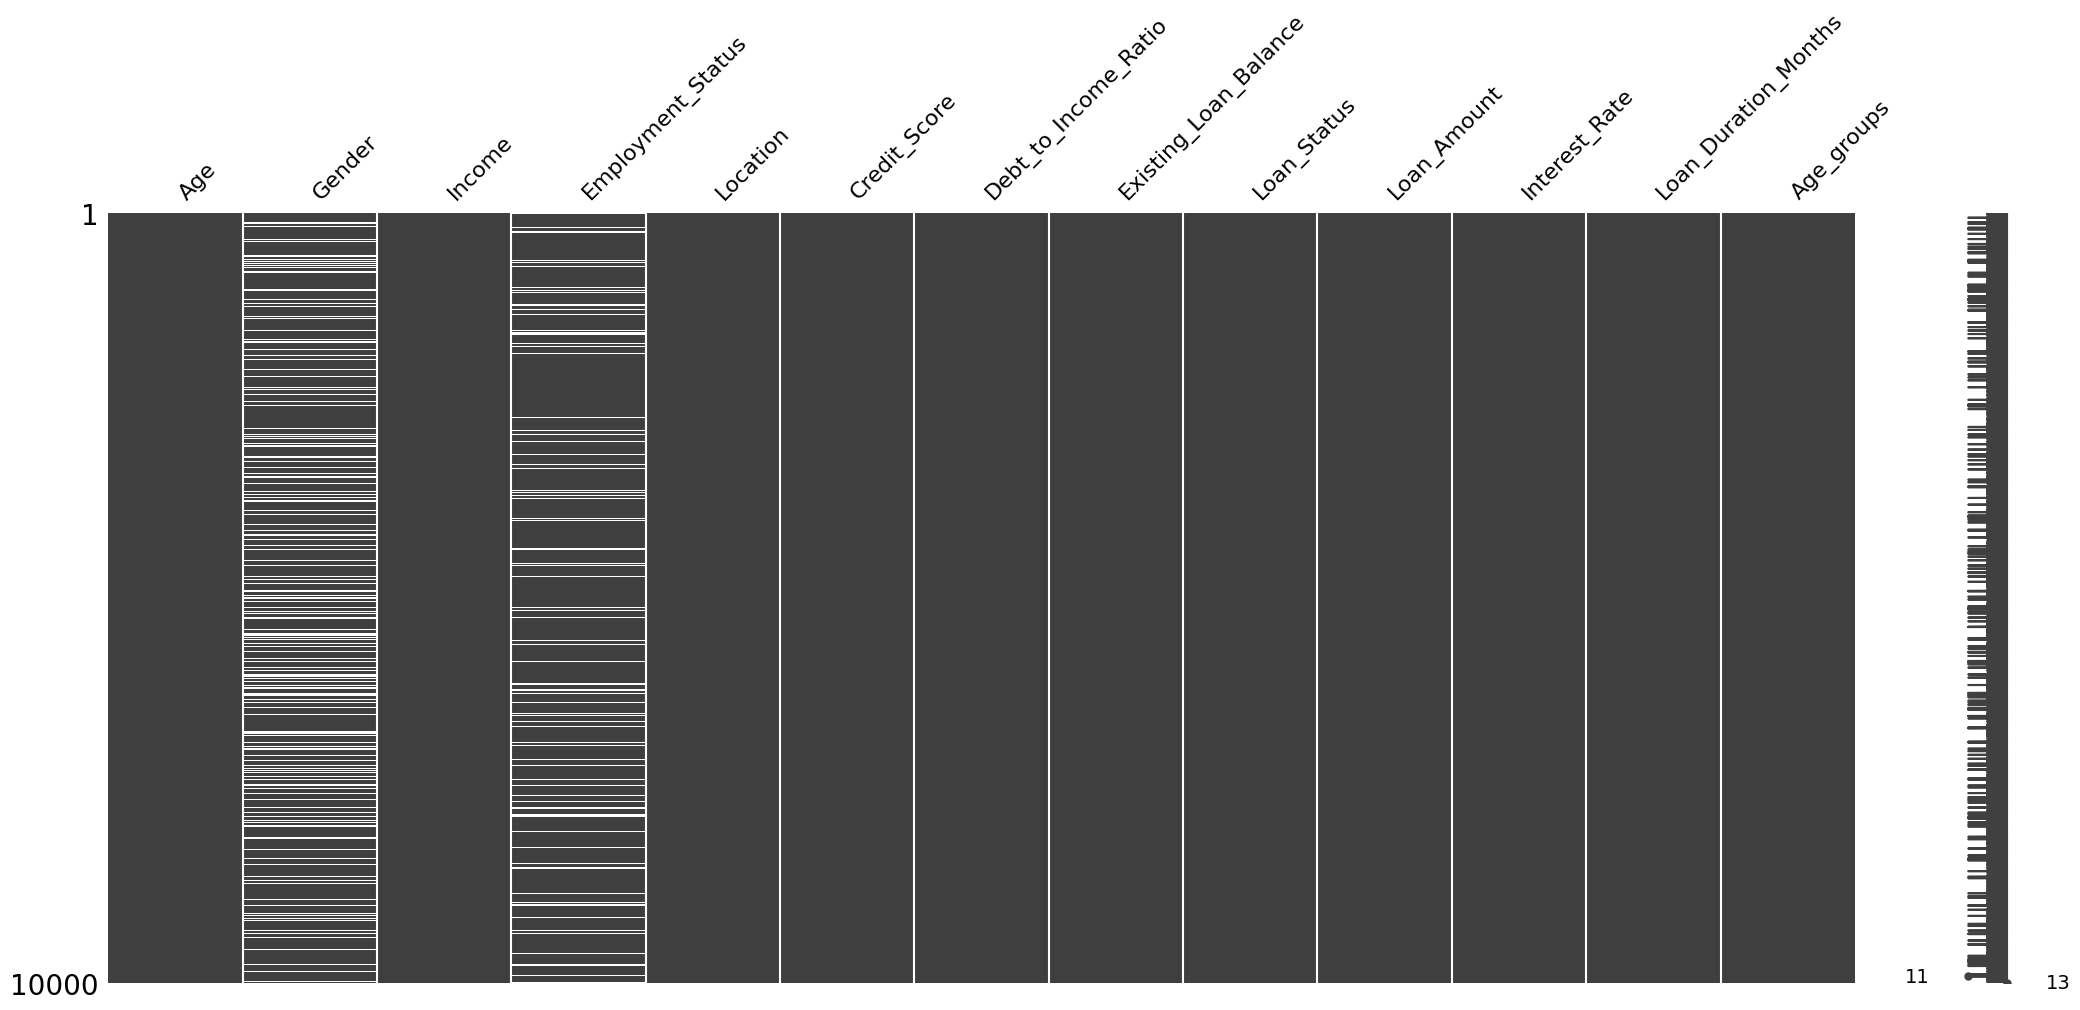

In [7]:
# Gender and Employment Status as more null Values. 
msno.matrix(df)
plt.show()

In [8]:
# Employment_Status seems to be an important column in the dataset and has more NAN values, 
# Making necassary changes with employment_Status(NAN) values to Employed based on 

# 1)assuming that loan_status(Non-Default) as high probalitiy of being employed. so fill employed.

df.loc[df['Loan_Status']== 'Non-Default','Employment_Status']= df.loc[df['Loan_Status']=='Non-Default','Employment_Status'].fillna('Employed')
df.to_csv('loan_default_prediction_project_complete',index=False)

In [9]:
# After the data is filled we find 217 are still null values. 
df["Employment_Status"].isnull().value_counts()

Employment_Status
False    9783
True      217
Name: count, dtype: int64

In [10]:
pd.crosstab(df['Employment_Status'],df['Loan_Status'],margins=all)

Loan_Status,Default,Non-Default,All
Employment_Status,,,
Employed,1156,5607,6763
Unemployed,594,2426,3020
All,1750,8033,9783


In [11]:
df["Employment_Status"].unique()

array(['Employed', 'Unemployed', nan], dtype=object)

In [12]:
#df['Employment_Status'].sort_values(ascending=True, na_position='first').head(10)

In [13]:
# Now NA values in Employment_Status is 217.
null_column = df[df['Employment_Status'].isna()]
null_column

,Age,Gender,Income,Employment_Status,Location,Credit_Score,Debt_to_Income_Ratio,Existing_Loan_Balance,Loan_Status,Loan_Amount,Interest_Rate,Loan_Duration_Months,Age_groups
6,56,Female,36182.461403,NaN,Urban,344,0.786791,38013.958210,Default,18902.137804,18.838415,66,60-80
11,41,Female,25664.281097,NaN,Urban,706,0.420448,44486.070681,Default,19231.429017,17.110298,12,40-60
12,53,Female,50119.215628,NaN,Suburban,743,0.701868,35321.352481,Default,36651.235877,12.636722,16,60-80
61,21,NaN,69853.859443,NaN,Rural,804,0.458836,3485.876367,Default,21049.302649,8.367206,66,20-40
90,46,Male,91167.251309,NaN,Suburban,408,0.076080,6511.342237,Default,10777.976176,4.816273,48,40-60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9757,53,Female,73168.221180,NaN,Suburban,780,0.696898,35187.263837,Default,19300.293078,7.280397,49,60-80
9758,22,Female,44807.422693,NaN,Suburban,528,0.721523,37756.467038,Default,24239.773551,10.799120,44,20-40
9759,28,NaN,55690.713046,NaN,Suburban,439,0.442398,18212.001740,Default,20201.751178,12.397494,69,20-40
9838,34,Female,72769.746785,NaN,Urban,331,0.969264,26306.952089,Default,27710.937014,14.356038,29,20-40


In [14]:
#chi square test for "Gender" column to Loan_status (y_lable)
import pandas as pd
import  scipy.stats as stats
contingency_table = pd.crosstab(df['Gender'],df['Loan_Status'])
contingency_table
chi2,p,dof,expected = stats.chi2_contingency(contingency_table)

print(f"Chi_square Statistics :{chi2}")
print(f"p-value: {p}")
print(f"degrees of freedom {dof}")
print("Expected table value:")
print(pd.DataFrame(expected, columns=contingency_table.columns, index = contingency_table.index))
if p < 0.05:
    print("Reject Null Hypothesis: Independent and Dependent variables are related.")
else:
    print("Fail to Reject Null Hypothesis: Independent and Dependent variables are independent.")

# so we conclude that "Gender" column doesnt serve more importants to our dependent column (Loan_status)

Chi_square Statistics :0.04387745406150033
p-value: 0.8340817750736846
degrees of freedom 1
Expected table value:
Loan_Status    Default  Non-Default
Gender                             
Female       801.76065   3232.23935
Male         789.23935   3181.76065
Fail to Reject Null Hypothesis: Independent and Dependent variables are independent.


In [15]:
# Gender column is dropped. 
df.drop('Gender',inplace = True, axis = 1)

In [16]:
df.loc[df['Loan_Status']== 'Default','Employment_Status'] = df.loc[df['Loan_Status']=='Default','Employment_Status'].fillna('Unemployed')
df.to_csv('loan_default_prediction_project_complete',index=False)


In [17]:
# Now we see that employent_status is filled. 

df["Employment_Status"].value_counts().sum()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Age                    10000 non-null  int64   
 1   Income                 10000 non-null  float64 
 2   Employment_Status      10000 non-null  object  
 3   Location               10000 non-null  object  
 4   Credit_Score           10000 non-null  int64   
 5   Debt_to_Income_Ratio   10000 non-null  float64 
 6   Existing_Loan_Balance  10000 non-null  float64 
 7   Loan_Status            10000 non-null  object  
 8   Loan_Amount            10000 non-null  float64 
 9   Interest_Rate          10000 non-null  float64 
 10  Loan_Duration_Months   10000 non-null  int64   
 11  Age_groups             10000 non-null  category
dtypes: category(1), float64(5), int64(3), object(3)
memory usage: 869.5+ KB


In [18]:
Loan_Emp_stat_Crs=pd.crosstab(df['Loan_Status'],df['Employment_Status'])
Loan_Emp_stat_Crs

Employment_Status,Employed,Unemployed
Loan_Status,,
Default,1156,811
Non-Default,5607,2426


In [19]:
# comparing Income and Location to see if Employment status can be enhanced.Since the values are diversed we cant 
#make any changes. 
Inco_location = pd.crosstab(df['Location'],df['Income']<= 25000)
Inco_location

Income,False,True
Location,,
Rural,3074,229
Suburban,3118,200
Urban,3178,201


In [20]:
#comparing Age and Location 
Age_location = pd.crosstab(df['Location'],df['Age']>=64)
Age_location

Age,False,True
Location,,
Rural,3225,78
Suburban,3237,81
Urban,3310,69


In [21]:
Loan_sta_location = pd.crosstab(df['Location'],df['Loan_Status'],margins=all)
Loan_sta_location 

Loan_Status,Default,Non-Default,All
Location,,,
Rural,663,2640,3303
Suburban,653,2665,3318
Urban,651,2728,3379
All,1967,8033,10000


Text(0.5, 1.0, 'Class Imbalance')

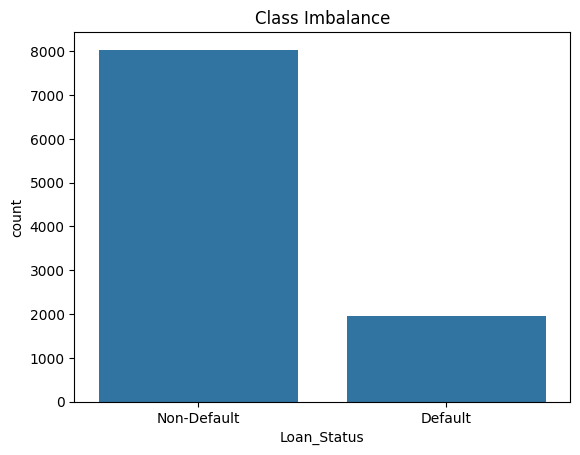

In [22]:
# checking the distribution of Loan_Status
sns.countplot(data = df, x='Loan_Status')
plt.title('Class Imbalance')

In [23]:
# the Label column has less defaulter, so our prediction accuracy might go wrong. 
# We will use technique called SMORTE 

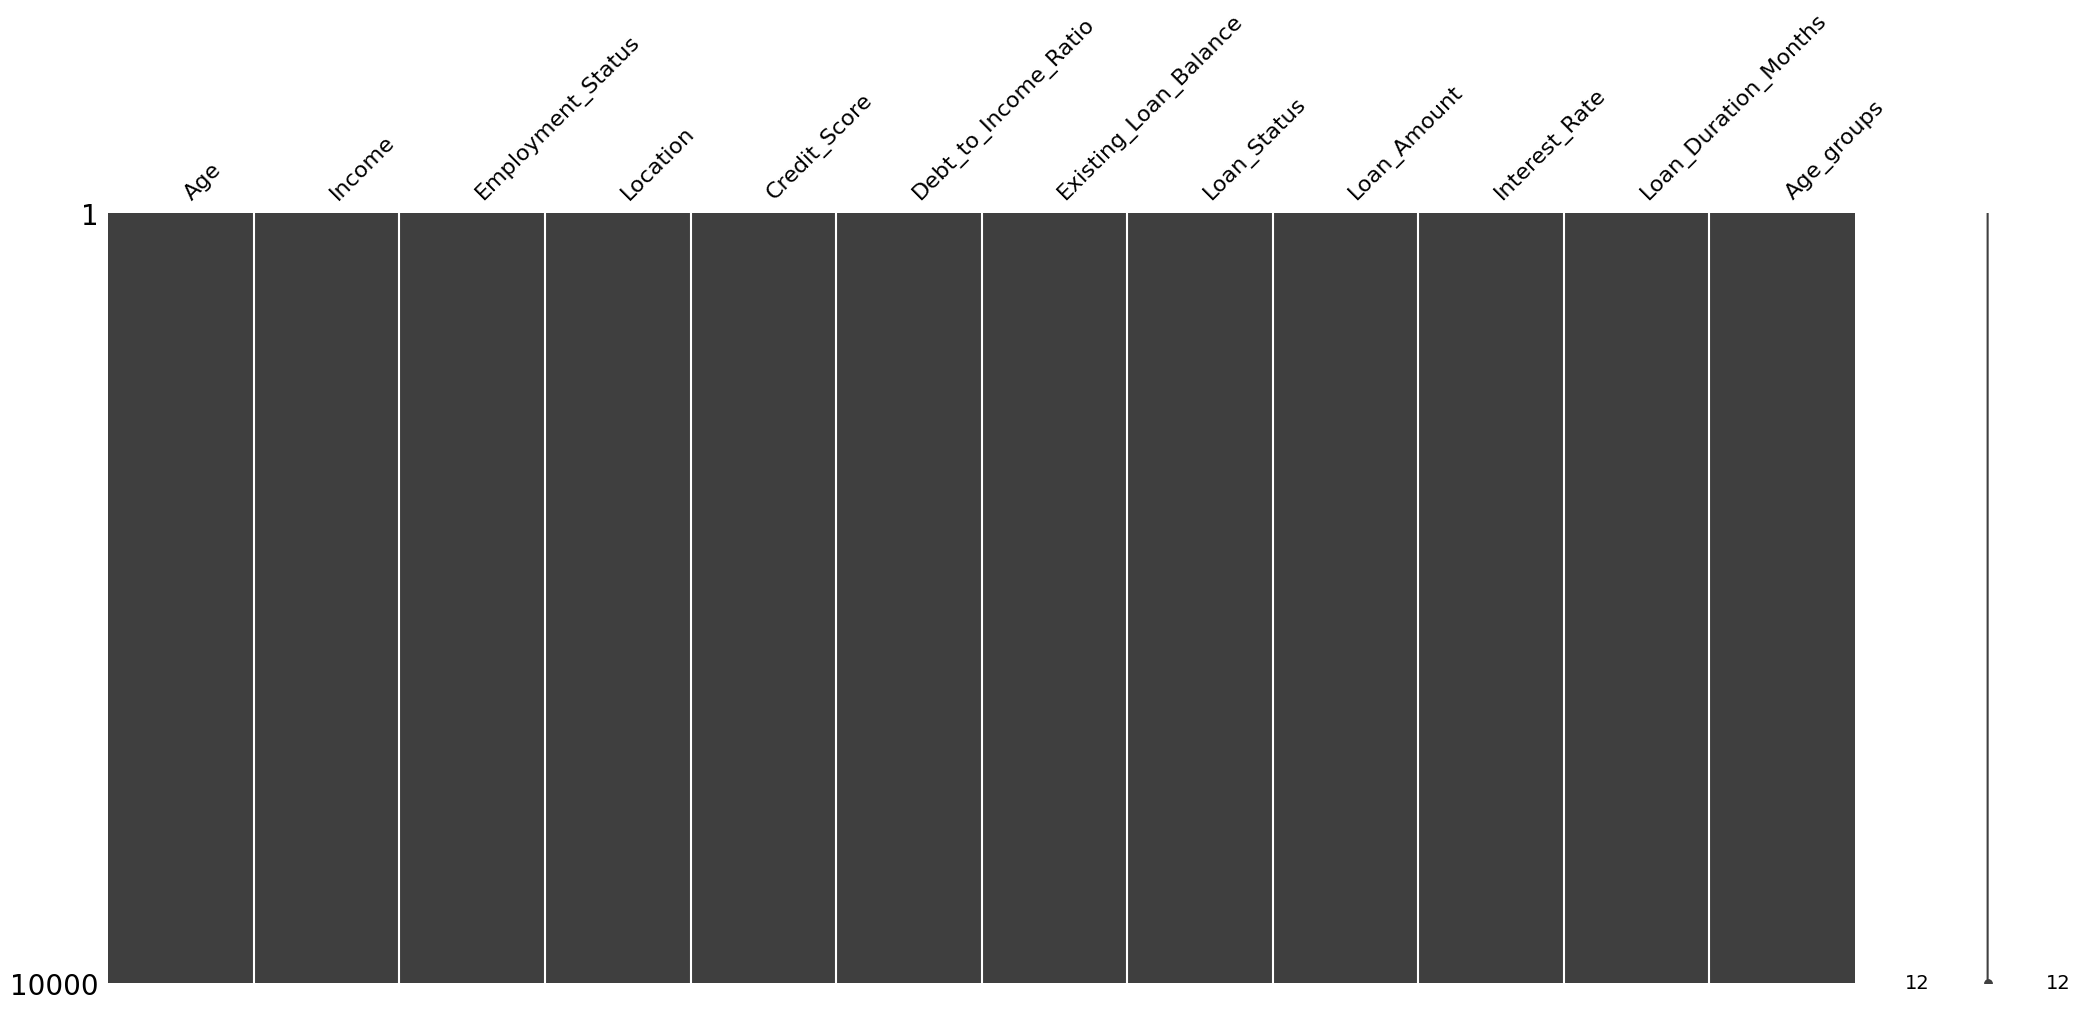

In [24]:
# null values Distribution is clear. 
msno.matrix(df)
plt.show()

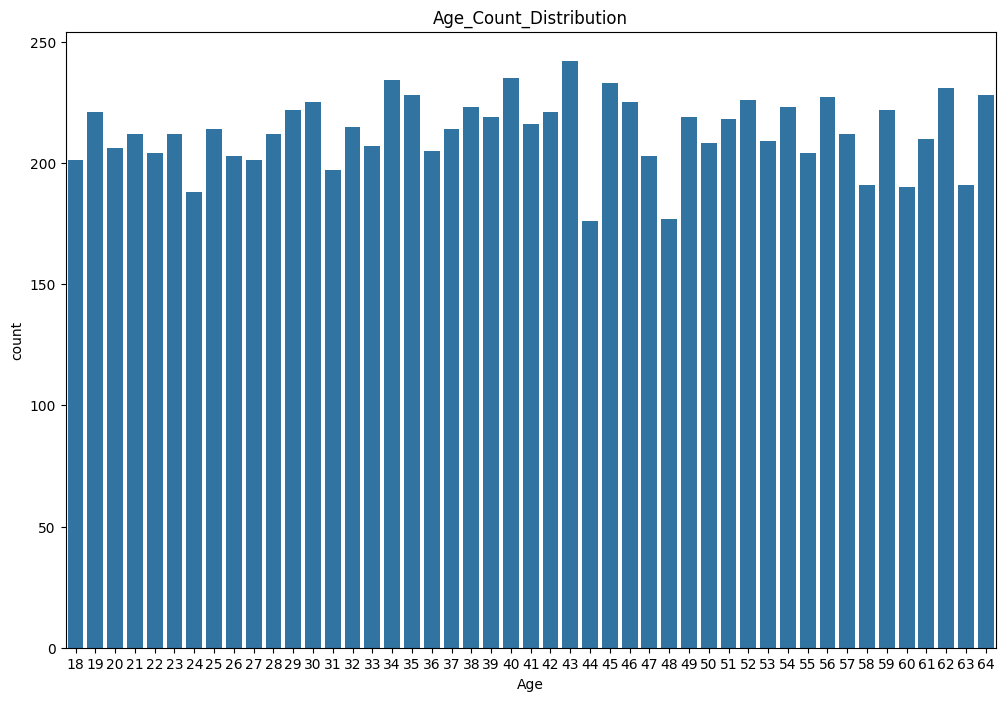

In [25]:
fig,ax = plt.subplots(figsize=(12,8))
sns.countplot(data= df, x='Age')
plt.title('Age_Count_Distribution')
plt.show()

Text(0.5, 1.0, 'Age_group_Pie_chart')

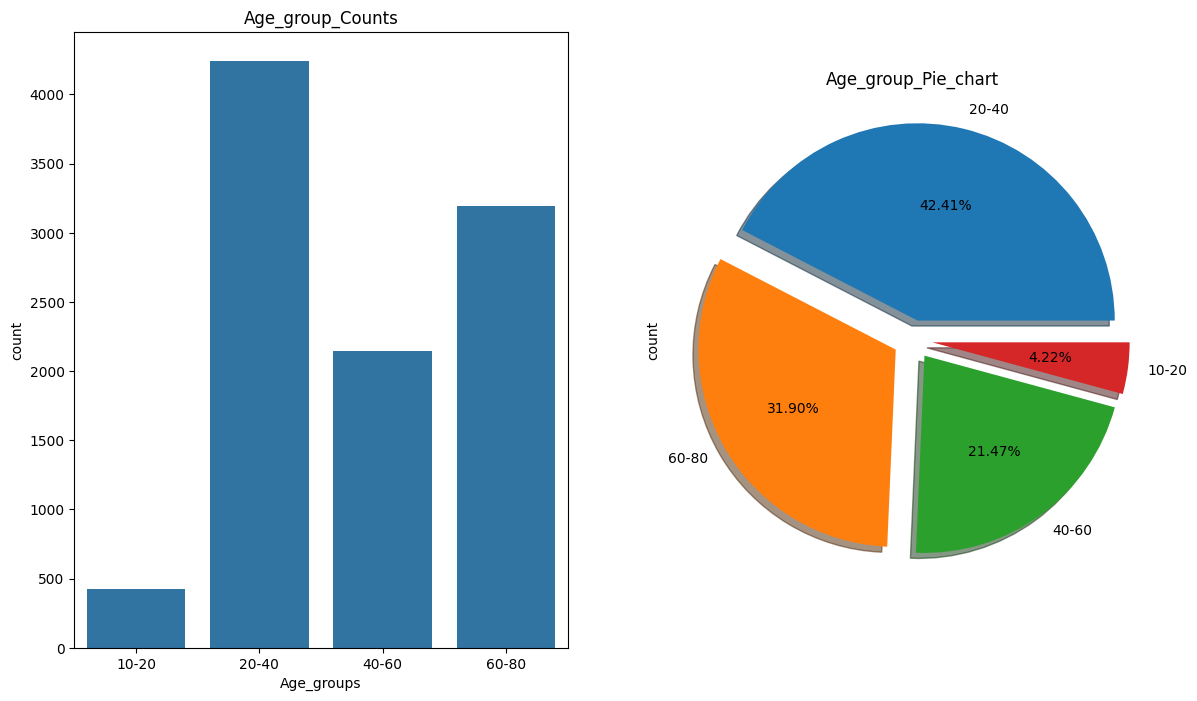

In [26]:
fig,axs= plt.subplots(1,2, figsize= (14,8))
sns.countplot(data=df,x='Age_groups',ax=axs[0])
axs[0].set_title('Age_group_Counts')
df['Age_groups'].value_counts().plot(x=None,y=None,kind='pie',shadow= True,explode=([0.1,0.1,0.1,0.1]),autopct='%1.2f%%',ax=axs[1])
axs[1].set_title('Age_group_Pie_chart')




<Axes: xlabel='Age_groups', ylabel='Count'>

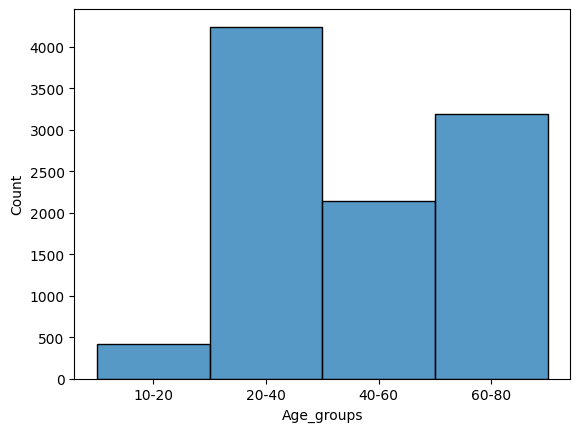

In [27]:
#sns.kdeplot(data=df,x='Age', fill= True)

sns.histplot(data=df, x="Age_groups")

<Axes: xlabel='Income', ylabel='Loan_Status'>

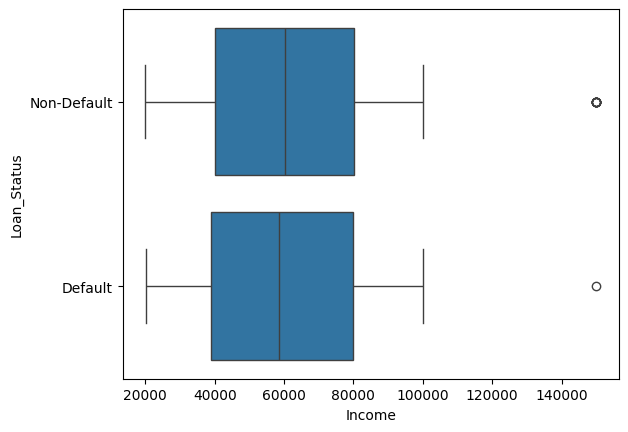

In [28]:
#outlairs deducted in Income. 
sns.boxplot(data=df, x='Income',y='Loan_Status')

<Axes: xlabel='Age_groups', ylabel='Count'>

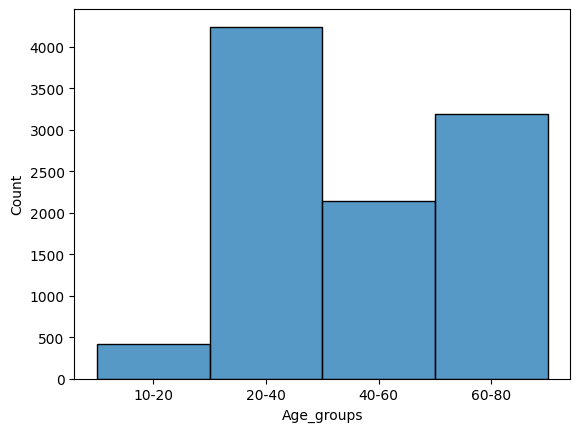

In [29]:
sns.histplot(data=df,x='Age_groups')

In [30]:
#from scipy.stats import boxcox

#df['Age_nol'], lambda_ = boxcox(df['Age'] + 1)  # +1 to avoid zero issues
#cross = pd.crosstab(df['Age_nol'],df['Age'])
#cross
#sns.histplot(data= df,x='Age_nol')


In [31]:
#mu, sigma = 0, 1  # Mean = 0, Std Dev = 1
#data = np.random.normal(mu, sigma)

#plt.hist(x= 'Age', bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')

# Plot normal curve
#x = np.linspace(min(data), max(data), 100)
#pdf = stats.norm.pdf(x, mu, sigma)  # Probability Density Function (PDF)
#plt.plot(x, pdf, 'r', linewidth=2)

# Labels
#plt.title("Normal Distribution (Mean=0, Std Dev=1)")
#plt.xlabel("Value")
#plt.ylabel("Density")
#plt.grid()
#plt.show()

In [32]:
#IQR for Income Column 
q1 = df['Income'].quantile(0.25)
q3 = df['Income'].quantile(0.75)
IQR = q3-q1
#df['Income'].mean() = 60026
min_value = q1-1.5*IQR
max_value = q3+1.5*IQR
df = df[(df['Income'] >= min_value) & (df['Income'] <= max_value)]

In [33]:
df['Income'].isna().count()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Age                    9990 non-null   int64   
 1   Income                 9990 non-null   float64 
 2   Employment_Status      9990 non-null   object  
 3   Location               9990 non-null   object  
 4   Credit_Score           9990 non-null   int64   
 5   Debt_to_Income_Ratio   9990 non-null   float64 
 6   Existing_Loan_Balance  9990 non-null   float64 
 7   Loan_Status            9990 non-null   object  
 8   Loan_Amount            9990 non-null   float64 
 9   Interest_Rate          9990 non-null   float64 
 10  Loan_Duration_Months   9990 non-null   int64   
 11  Age_groups             9990 non-null   category
dtypes: category(1), float64(5), int64(3), object(3)
memory usage: 946.5+ KB


In [34]:
#df = df.dropna(subset=["Loan_Status"])

In [35]:
#for col in df.select_dtypes(include=["object"]).columns:
    #df[col] = pd.to_numeric(df[col], errors="coerce")  # Converts non-numeric values to NaN

<Axes: xlabel='Income', ylabel='Count'>

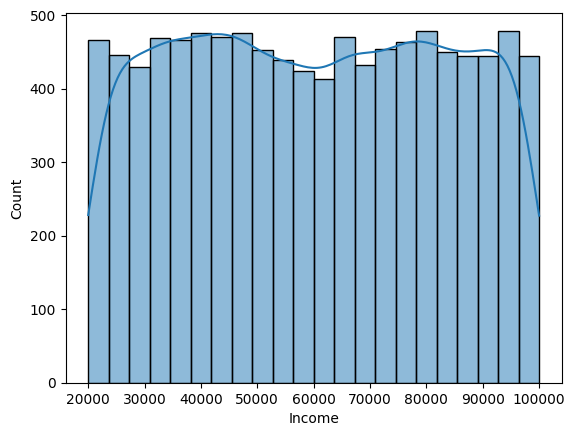

In [36]:
sns.histplot(data=df,x='Income',kde=True)

In [37]:
#mu_pop = df['Income'].mean()
#sns.scatterplot(data=df,x='Income',y='Loan_Status')
#df['Loan_Status'].value_counts()

In [38]:
#fig, axs = plt.subplots(1,2, figsize = (10,6))
#sns.scatterplot(data= df,x='Loan_Status',y='Income',ax=axs[0])
#df['Loan_Status'].value_counts().plot(kind='pie',shadow=True,explode=([0.1,0.1]),autopct='%1.2f%%')

In [39]:
# inference of the data

#infer_Inc = df['Income'].sample(n=5000,random_state=24)
#sns.histplot(data=infer_Inc,kde=True,bins=30)
#mu = infer_Inc.mean()
#mu


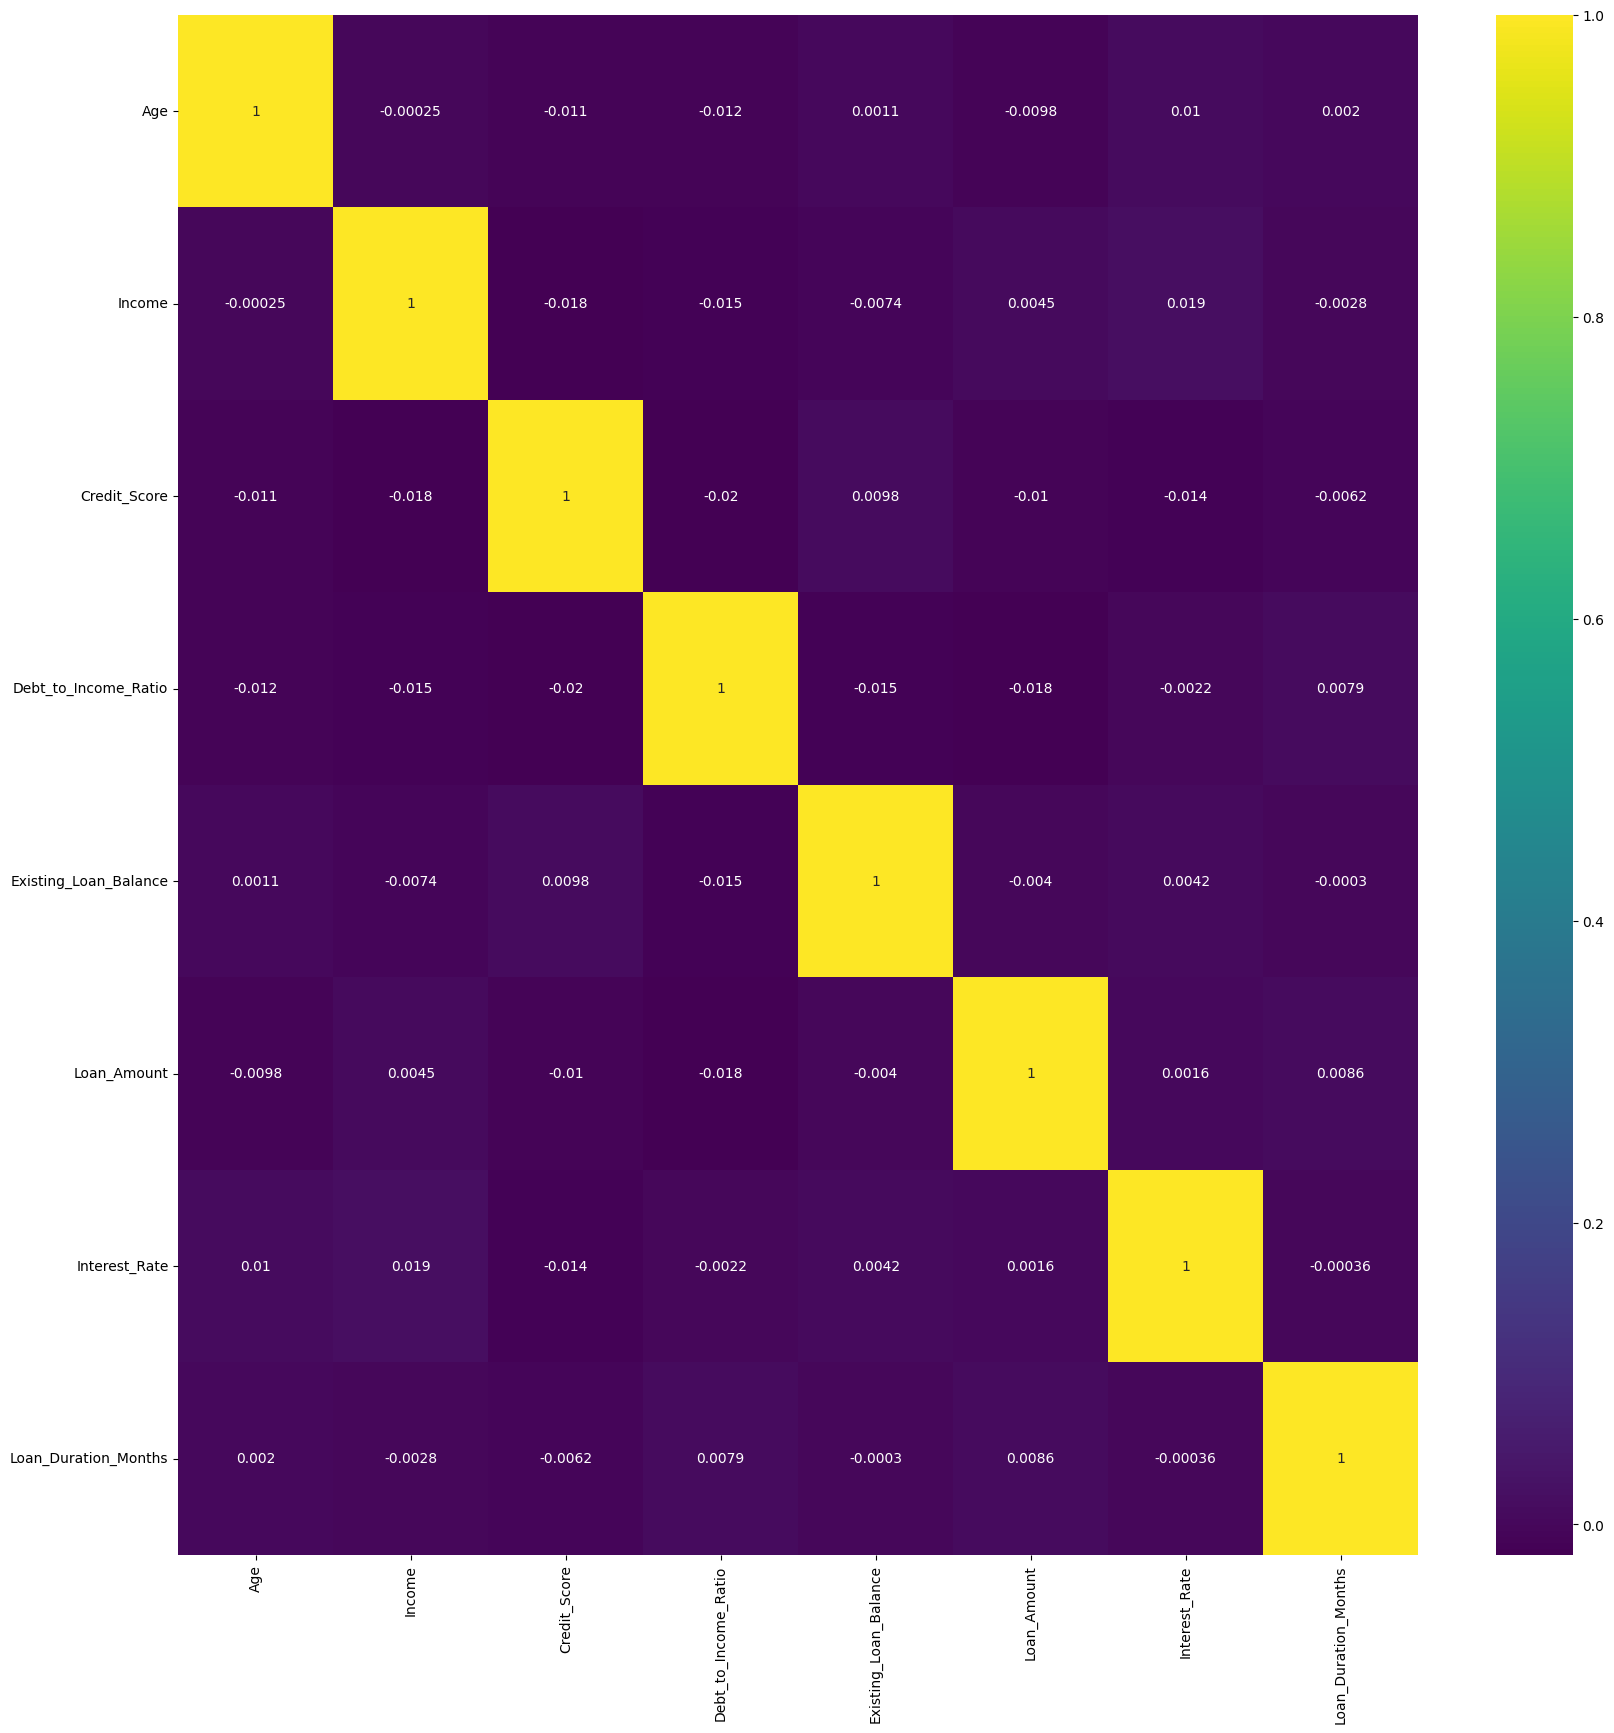

In [40]:
# Create a figure and plot the heatmap
plt.figure(figsize=(20, 20))
heat_map = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
heat_map.set_yticklabels(heat_map.get_yticklabels(), rotation=0)
plt.show()

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [42]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Calculate the ratio of negative to positive classes for XGBoost
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import cross_validate,RandomizedSearchCV
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9990 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Age                    9990 non-null   int64   
 1   Income                 9990 non-null   float64 
 2   Employment_Status      9990 non-null   object  
 3   Location               9990 non-null   object  
 4   Credit_Score           9990 non-null   int64   
 5   Debt_to_Income_Ratio   9990 non-null   float64 
 6   Existing_Loan_Balance  9990 non-null   float64 
 7   Loan_Status            9990 non-null   object  
 8   Loan_Amount            9990 non-null   float64 
 9   Interest_Rate          9990 non-null   float64 
 10  Loan_Duration_Months   9990 non-null   int64   
 11  Age_groups             9990 non-null   category
dtypes: category(1), float64(5), int64(3), object(3)
memory usage: 946.5+ KB


<Axes: xlabel='Loan_Status', ylabel='count'>

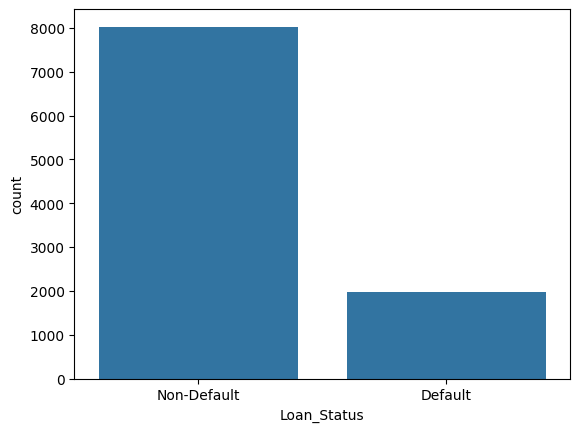

In [44]:
df['Loan_Status'].value_counts(normalize=True)
sns.countplot(x='Loan_Status', data=df)

In [45]:
# Separate features and target variable
X = df.drop(columns=['Loan_Status','Age_groups'])
y = df['Loan_Status']


In [46]:
from sklearn.preprocessing import LabelEncoder
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [47]:
sm = SMOTE(random_state=0, k_neighbors= 6)
X_res, Y_res = sm.fit_resample(X, y)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_res, Y_res, test_size=0.2, random_state=42)

In [51]:
label_map = {'Non-Default': 0, 'Default': 1}
y_train = y_train.map(label_map)
y_test = y_test.map(label_map)

In [56]:
models = {
    'Balanced Random Forest': BalancedRandomForestClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=100, random_state=42)
}

In [ ]:
for name, model in models.items():
    results=[]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append([name, accuracy, precision, recall, f1, roc_auc])
    
    print(results)

